In [1]:
import numpy as np
from functools import partial
from matplotlib import pyplot as plt
from cycler import cycler

def quad(a,b,c,x): return a*x**2 + b*x + c
def make_quad(a,b,c): return partial(quad, a, b, c)

def plot_function(f, ylim, title):
    x = np.linspace(-2, 3, 400)
    plt.plot(x, f(x))
    plt.ylim(ylim)
    plt.title(title)
    plt.rcParams["axes.prop_cycle"] = cycler(color=["tab:blue","tab:orange","tab:green","tab:red"])
    plt.show()

In [2]:
from numpy.random import normal, seed, uniform
np.random.seed(42)

def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1 + noise(x, mult)) + noise(x, add)

In [3]:
f = make_quad(3,2,1)
f(5)

86

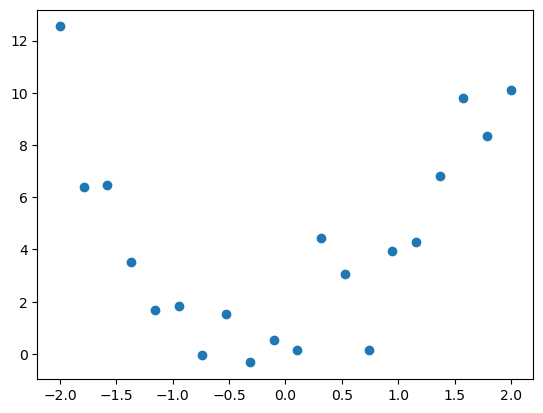

In [4]:
import torch
from matplotlib import pyplot as plt

x = torch.linspace(-2, 2, steps=20)[:, None]
y = add_noise(f(x), 0.3, 1.5)
plt.scatter(x,y)

In [5]:
def mse(preds, acts): return ((preds-acts)**2).mean()

In [6]:
from ipywidgets import interact

@interact(a=1.5,b=1.5,c=1.5)
def plot_quad(a,b,c):
    f = make_quad(a,b,c)
    plt.scatter(x,y)
    loss = mse(f(x),y)
    plot_function(f, ylim=[-1, 10], title=f"MSE: {loss:0.2f}")
    #plt.show()

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…